# This notebook shows how to fit a linear resonator in the reflection configuration.

In [1]:
from __future__ import division, absolute_import, print_function
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from resonator import background, reflection, see

Create data using the model plus gaussian noise. The model is the product of the reflection resonator model and a background model, which in this case assumes that the magnitude is independent of frequency and that the phase is described by an offset and an electrical delay, which adds a phase that is linearly dependent on frequency.

In [ ]:
import pandas as pd
import numpy as np

# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_critical_coupling_-20dBm_10kHzbdw.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_critical_coupling_-50dBm_1MHzbdw.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_critical_coupling_-50dBm_10kHzbdw.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_critical_coupling_-50dBm_50kHzbdw.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_overcoupled_less_-50dBm_10kHzbdw.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_overcoupled_more_-20dBm_10kHzbdw.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_undercoupled_-50dBm_10kHzbdw.csv", skiprows=2)

df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/6.csv", skiprows=2)

df.columns = ['frequency', 'S21_db', 'S21_deg']
df['S21'] = np.float_power(10, df['S21_db'].to_numpy()/20)

# Filter frequencies between 31 GHz and 39 GHz
freq_min = 9.7e9
freq_max = 9.78e9
df = df[(df['frequency'] >= freq_min) & (df['frequency'] <= freq_max)]

data = df['S21'].to_numpy() * np.exp(1j * np.deg2rad(df["S21_deg"])).to_numpy()
frequency = df["frequency"].to_numpy()
print(df.head())

      frequency    S21_db    S21_deg       S21
0  9.350000e+09 -4.072823 -93.558544  0.625689
1  9.350050e+09 -4.062980 -93.682662  0.626399
2  9.350100e+09 -4.072959 -93.906119  0.625680
3  9.350150e+09 -4.057511 -94.020676  0.626793
4  9.350200e+09 -4.059313 -94.181482  0.626663


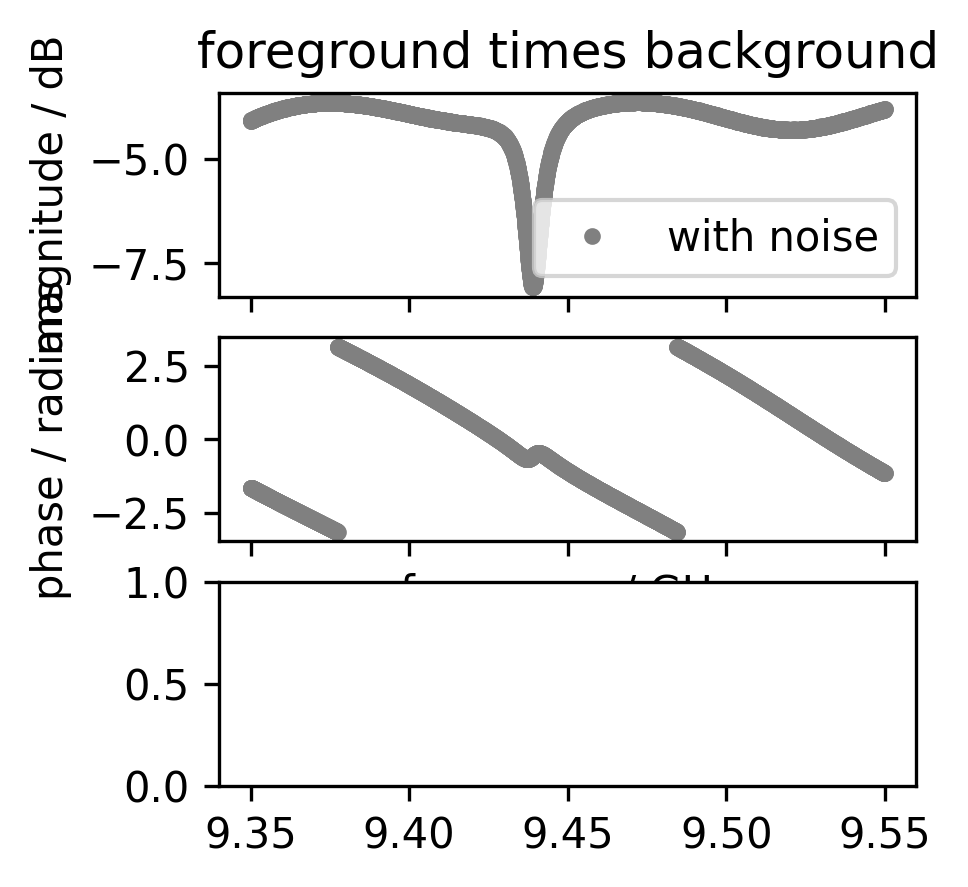

In [ ]:
fig, (ax_mag, ax_phase, ax_real_imag) = plt.subplots(3, 1, sharex=True, figsize=(3, 3), dpi=300)

ax_mag.set_ylabel('magnitude / dB')
ax_mag.plot(1e-9 * frequency, 20 * np.log10(np.abs(data)), '.', color='gray', label='with noise')
ax_mag.set_title('foreground times background')
ax_mag.legend()

ax_phase.set_xlabel('frequency / GHz')
ax_phase.set_ylabel('phase / radians')
ax_phase.plot(1e-9 * frequency, np.angle(data), '.', color='gray', label='with noise')

## Fit the model to the data using a LinearReflectionFitter.

If no errors are given, the fitting assumes equal errors for each point and thus equal weights, so errors are not generally necessary unless they vary between points.

In [58]:
import lmfit

params = lmfit.Parameters()
params = lmfit.Parameters()
params.add(name='internal_loss', value=1e-9) 
resonator = reflection.LinearReflectionFitter(frequency=frequency, data=data, params=params, background_model=background.MagnitudePhaseDelay())
print(resonator.result.fit_report())  # result is a lmfit.model.ModelResult object

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_reflection))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 36
    # data points      = 800
    # variables        = 6
    chi-square         = 0.06131637
    reduced chi-square = 7.7225e-05
    Akaike info crit   = -7569.05613
    Bayesian info crit = -7540.94846
    R-squared          = np.complex128(1617949245353.5884-3936645748914.1895j)
[[Variables]]
    frequency_reference:  9.740048e+09 (fixed)
    magnitude:            0.72469403 +/- 5.5226e-04 (0.08%) (init = 0.7035125)
    phase:               -3.07271736 +/- 6.8316e-04 (0.02%) (init = -3.040824)
    delay:               -7.0058e-09 +/- 5.2686e-12 (0.08%) (init = -6.045859e-09)
    resonance_frequency:  9.7415e+09 +/- 11987.9463 (0.00%) (init = 9.741448e+09)
    coupling_loss:        4.0708e-04 +/- 1.4198e-06 (0.35%) (init = 0.0006083315)
    internal_loss:        5.8978e-04 +/- 3.3153e-06 (0.56%) (init = 1e-09)
[[Correlations]] (unreport

## Plot the data

Use the `see.py` fitting module to plot the data, model, and resonance. These functions create a new figure and axes by default, but can also be used to plot data on existing axes, as shown below.

Note that the normalized (resonator plane) data forms a circle in the complex plane even though the raw data has a more complicated shape due to the background.

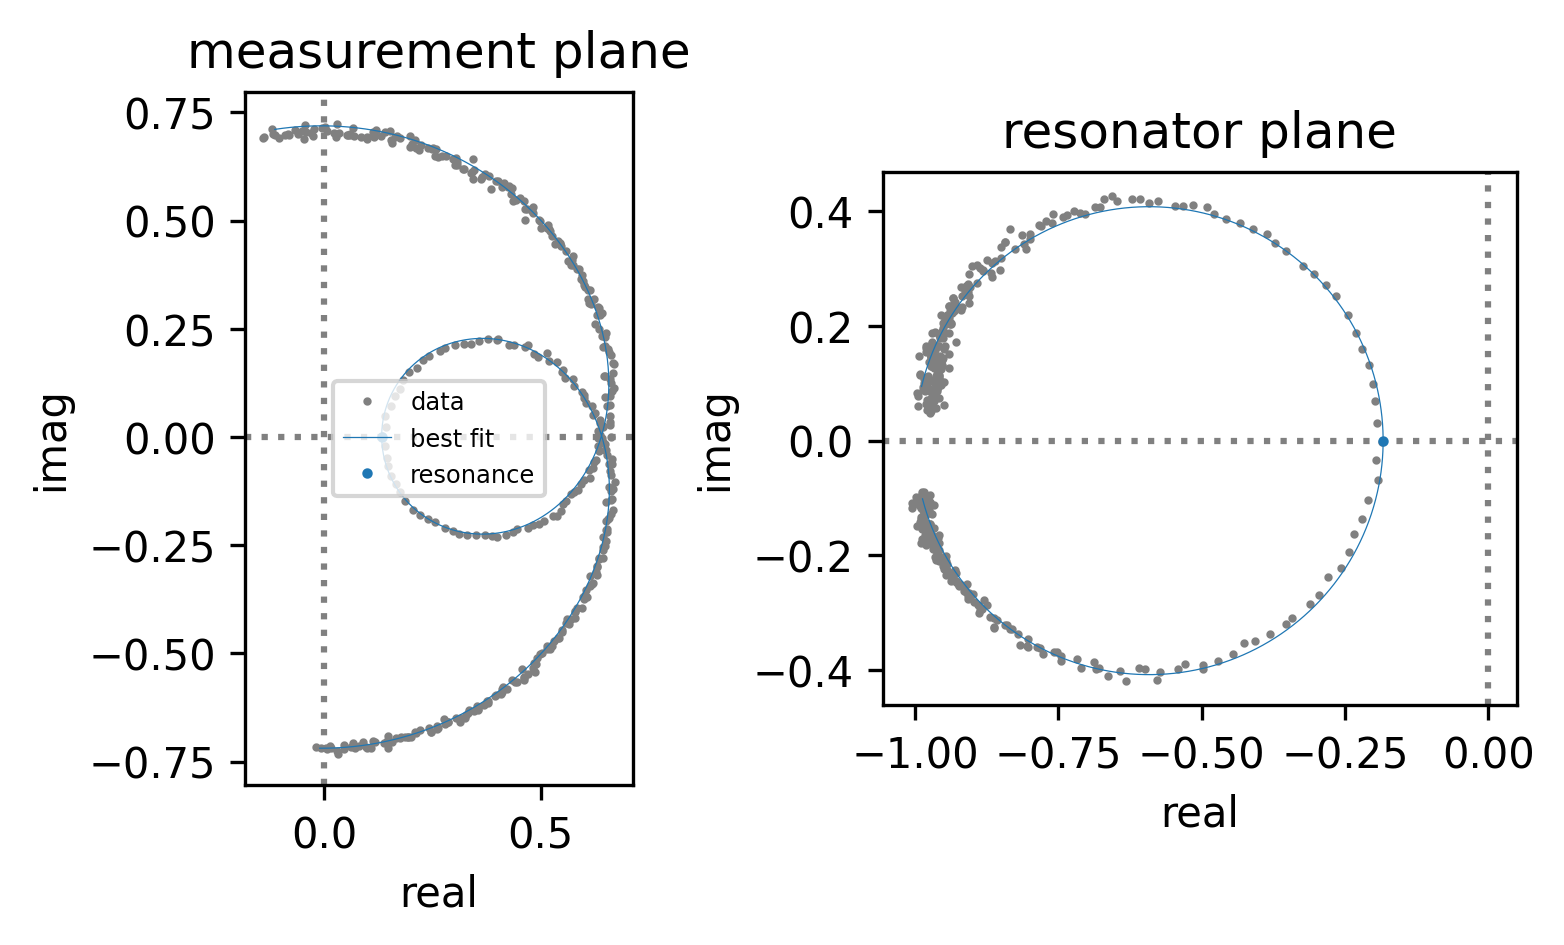

In [59]:
fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(6, 3), dpi=300)  # Adjust these values for your plot settings
ax_raw.set_title('measurement plane')
ax_norm.set_title('resonator plane')
see.real_and_imaginary(resonator=resonator, axes=ax_raw, normalize=False)
see.real_and_imaginary(resonator=resonator, axes=ax_norm, normalize=True)
ax_raw.legend(fontsize='xx-small');

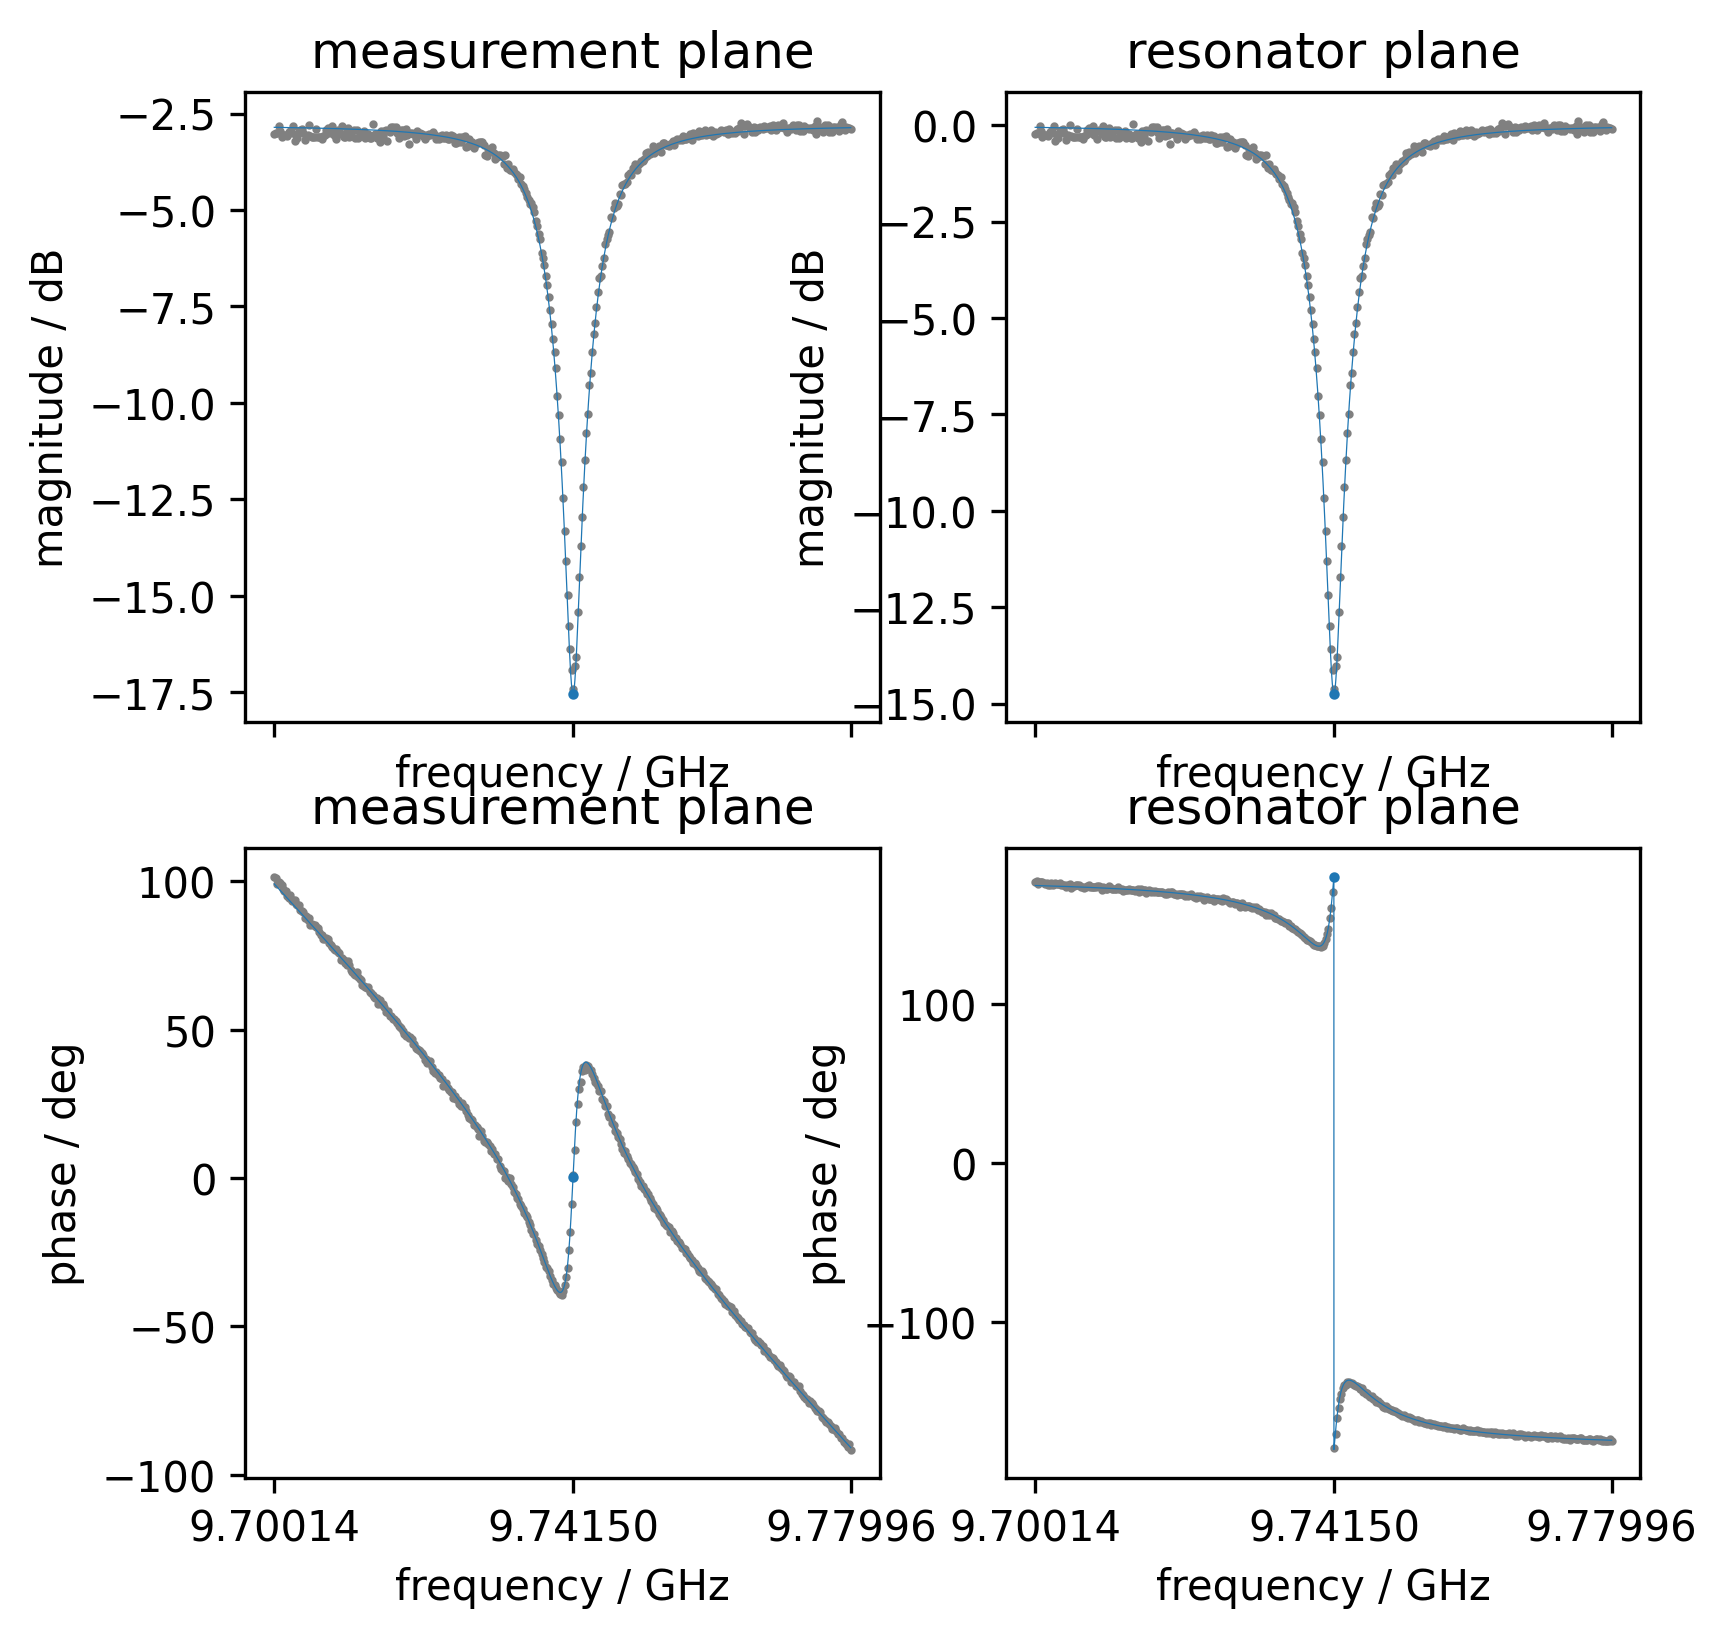

In [60]:
fig, axes = plt.subplots(2, 2, sharex='all', figsize=(6, 6), dpi=300)  # Adjust these values for your plot settings
ax_raw_mag, ax_norm_mag, ax_raw_phase, ax_norm_phase = axes.flatten()
ax_raw_mag.set_title('measurement plane')
ax_norm_mag.set_title('resonator plane')
ax_raw_phase.set_title('measurement plane')
ax_norm_phase.set_title('resonator plane')
see.magnitude_vs_frequency(resonator=resonator, axes=ax_raw_mag, normalize=False, frequency_scale=1e-9)
see.magnitude_vs_frequency(resonator=resonator, axes=ax_norm_mag, normalize=True, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_raw_phase, normalize=False, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_norm_phase, normalize=True, frequency_scale=1e-9);

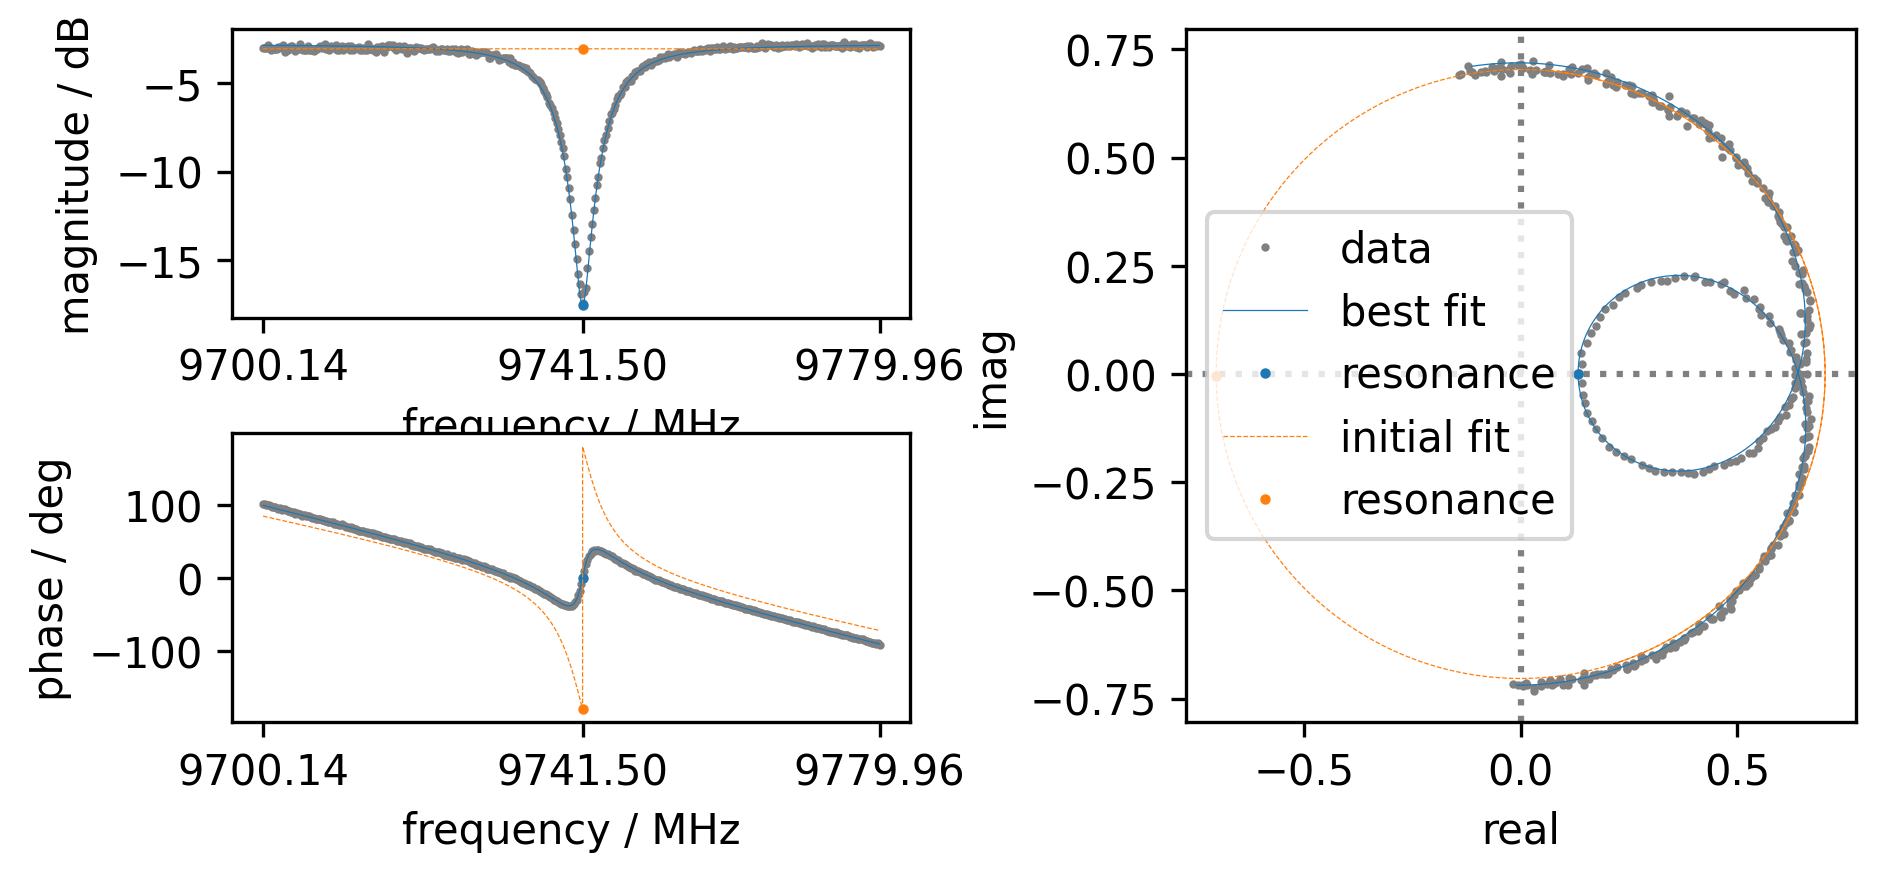

In [61]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=resonator, plot_initial=True, frequency_scale=1e-6, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend();